# 32 — Diabetes Distress (PAID-5) vs Depression (CES-D-10)

**Purpose**: NB29–31 measured depression with the CES-D-10. But diabetes care also uses a
*different* psychological screen — the **PAID-5** (Problem Areas in Diabetes, 5-item), which
captures **diabetes-specific emotional distress** (fear of complications, feeling overwhelmed,
frustration with management) rather than general depression. This notebook asks: **how do the
two relate? Do they measure the same thing, flag the same patients, and does their overlap
change with diabetes severity?**

**Why this matters**: Depression and diabetes distress are clinically distinct constructs that
are easy to confuse. If they diverge, screening for one will miss patients flagged by the other —
a direct implication for which instrument a clinic should use.

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year_of_birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — CES-D-10 (`cestl`), PAID-5
  (`paidscore` + 5 items), and mhoccur comorbidity flags

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Build CES-D-10 + PAID-5 Master DataFrame
4. Analysis 1 — Distributions & Overall Correlation
5. Analysis 2 — Concordance: Do the Two Screens Flag the Same People?
6. Analysis 3 — Correlation by Diabetes Group
7. Analysis 4 — Correlation by Age Band
8. Analysis 5 — Item-Level: Which Distress Facets Track Depression?
9. Key Findings

---

In [1]:
# ── 1. Environment Setup ────────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import kruskal, mannwhitneyu, spearmanr, chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
COMPARISONS  = ['Pre-DM', 'Oral Med', 'Insulin']
GROUP_COLORS = {'Healthy': '#66C2A5', 'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}

AGE_BAND_EDGES  = [0, 50, 60, 70, 120]
AGE_BAND_LABELS = ['<50', '50–59', '60–69', '70+']

DEPRESSION_CUTOFF = 10   # CES-D-10 ≥ 10  = probable depression
PAID_CUTOFF       = 8    # PAID-5   ≥ 8   = high diabetes distress

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ───────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    if (_cwd / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd)
    elif (_cwd.parent / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd.parent)
    else:
        repo_root = str(_cwd)

    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']

print('\nLoading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows × {obs_raw.shape[1]} cols')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi

Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...

Loading observation.csv (~108 MB) ...
  707,126 rows × 22 cols


In [3]:
# ── 3. Build CES-D-10 + PAID-5 Master DataFrame ───────────────────
obs_raw['item_key']    = (obs_raw['observation_source_value'].astype(str)
                          .str.split(',', n=1).str[0].str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan

# ── CES-D-10 total (pre-computed `cestl`, 0–30) ──
cesd_total = (obs_raw[obs_raw['item_key'] == 'cestl']
              .groupby('person_id')['value_clean'].first().rename('cesd_total'))

# ── PAID-5: pre-computed total (`paidscore`, 0–20) + the 5 items (each 0–4) ──
PAID_ITEMS = {
    'paid_wr':   'Worrying about the future / complications',
    'paid_scrd': 'Feeling scared about living with diabetes',
    'paid_dpr':  'Feeling depressed when thinking about diabetes',
    'paid_cml':  'Coping with complications of diabetes',
    'paid_eng':  'Diabetes taking up too much mental energy',
}
paid_total = (obs_raw[obs_raw['item_key'] == 'paidscore']
              .groupby('person_id')['value_clean'].first().rename('paid_total'))
paid_items = (obs_raw[obs_raw['item_key'].isin(PAID_ITEMS)]
              .pivot_table(index='person_id', columns='item_key',
                           values='value_clean', aggfunc='first'))

# ── Comorbidity count (mhoccur) — context only ──
mh    = obs_raw[obs_raw['item_key'].str.startswith('mhoccur', na=False)]
dcols = [c for c in mh['item_key'].unique() if 'fallot' not in c and c != 'mhoccur_yn']
mh_wide = (mh[mh['item_key'].isin(dcols)]
           .pivot_table(index='person_id', columns='item_key',
                        values='value_clean', aggfunc='first').clip(upper=1))
comorbidity = mh_wide.sum(axis=1).rename('comorbidity_count')

# ── Merge everything ──
df = (participants[['person_id', 'study_group_code', 'study_group_label']]
      .merge(person[['person_id', 'age']],          on='person_id', how='left')
      .merge(cesd_total.reset_index(),               on='person_id', how='left')
      .merge(paid_total.reset_index(),               on='person_id', how='left')
      .merge(paid_items.reset_index(),               on='person_id', how='left')
      .merge(comorbidity.reset_index(),              on='person_id', how='left'))

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_band'] = pd.cut(df['age'], bins=AGE_BAND_EDGES, labels=AGE_BAND_LABELS, right=False)
df['age_band'] = pd.Categorical(df['age_band'], categories=AGE_BAND_LABELS, ordered=True)

df['depressed']     = (df['cesd_total'] >= DEPRESSION_CUTOFF).astype('float')
df['high_distress'] = (df['paid_total'] >= PAID_CUTOFF).astype('float')

ITEM_COLS = [c for c in PAID_ITEMS if c in df.columns]

print(f'Final df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'CES-D-10 (cestl):  {df["cesd_total"].notna().sum():,} scored '
      f'(mean {df["cesd_total"].mean():.2f}/30, depressed ≥{DEPRESSION_CUTOFF}: '
      f'{df["depressed"].mean()*100:.1f}%)')
print(f'PAID-5 (paidscore): {df["paid_total"].notna().sum():,} scored '
      f'(mean {df["paid_total"].mean():.2f}/20, high distress ≥{PAID_CUTOFF}: '
      f'{df["high_distress"].mean()*100:.1f}%)')
print(f'Both scores present: {df.dropna(subset=["cesd_total","paid_total"]).shape[0]:,}')
print(f'PAID items found: {ITEM_COLS}')

Final df: 2,280 rows × 15 cols
CES-D-10 (cestl):  2,277 scored (mean 5.85/30, depressed ≥10: 20.0%)
PAID-5 (paidscore): 2,229 scored (mean 4.00/20, high distress ≥8: 19.8%)
Both scores present: 2,227
PAID items found: ['paid_wr', 'paid_scrd', 'paid_dpr', 'paid_cml', 'paid_eng']


---
## 4. Analysis 1 — Distributions & Overall Correlation

> **Question**: Across the full cohort, how strongly does diabetes distress (PAID-5) correlate
> with general depression (CES-D-10)? Are they effectively the same measurement, or related but
> distinct?
>
> **Method**: Spearman (rank) and Pearson correlation between the two total scores, plus a
> scatter and the two score distributions. A high correlation (ρ > 0.7) would suggest redundancy;
> a moderate one (ρ ≈ 0.3–0.5) would mean they capture overlapping but different burden.

=== PAID-5 (diabetes distress) vs CES-D-10 (depression) — Overall ===
  n with both scores : 2,227
  Spearman rho       : 0.328  (p = 7.63e-57)
  Pearson  r         : 0.369
  Shared rank variance ≈ 10.7%

  PAID-5  : mean 4.00/20  | high distress (≥8): 20.2%
  CES-D-10: mean 5.85/30  | depressed (≥10): 19.9%


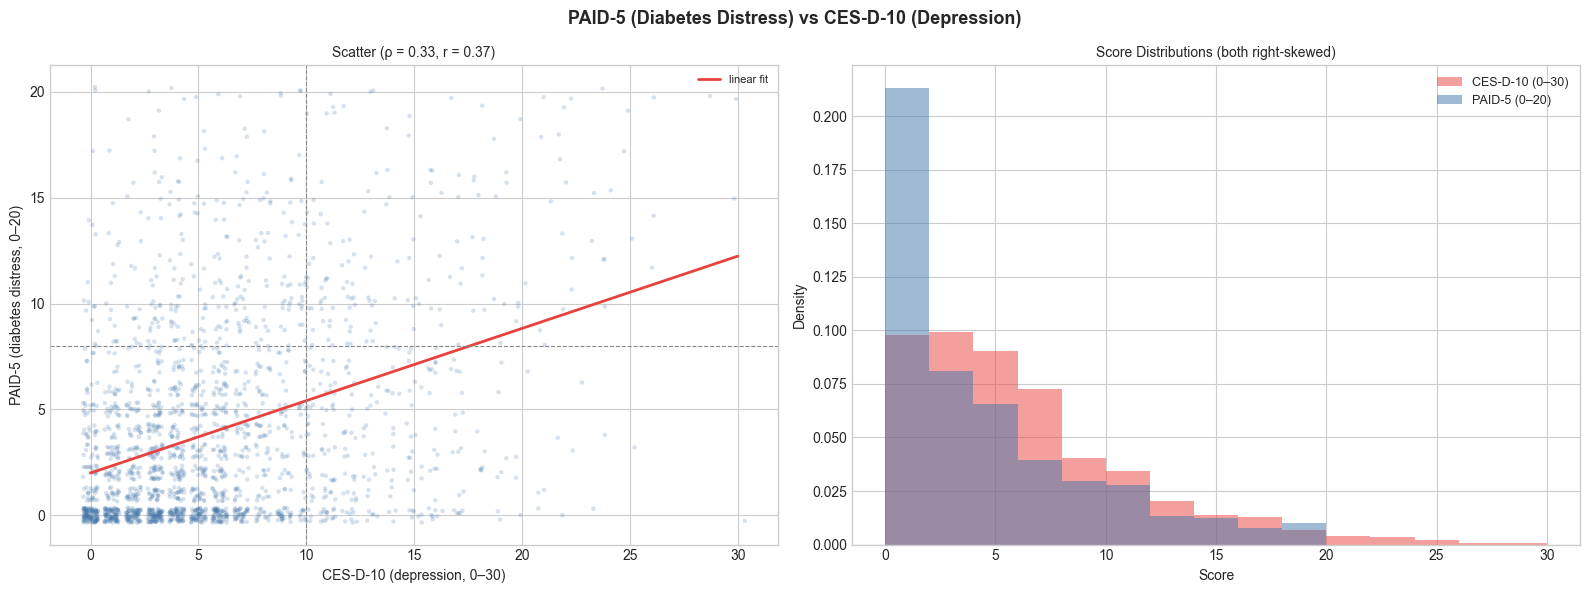

In [4]:
# ── Analysis 1: Distributions & Overall Correlation ───────────────
both = df.dropna(subset=['cesd_total', 'paid_total']).copy()

rho, p_rho = spearmanr(both['cesd_total'], both['paid_total'])
r_pear     = both['cesd_total'].corr(both['paid_total'])

print('=== PAID-5 (diabetes distress) vs CES-D-10 (depression) — Overall ===')
print(f'  n with both scores : {len(both):,}')
print(f'  Spearman rho       : {rho:.3f}  (p = {p_rho:.2e})')
print(f'  Pearson  r         : {r_pear:.3f}')
print(f'  Shared rank variance ≈ {rho**2*100:.1f}%')
print()
print(f'  PAID-5  : mean {both["paid_total"].mean():.2f}/20  | '
      f'high distress (≥{PAID_CUTOFF}): {(both["paid_total"]>=PAID_CUTOFF).mean()*100:.1f}%')
print(f'  CES-D-10: mean {both["cesd_total"].mean():.2f}/30  | '
      f'depressed (≥{DEPRESSION_CUTOFF}): {(both["cesd_total"]>=DEPRESSION_CUTOFF).mean()*100:.1f}%')

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PAID-5 (Diabetes Distress) vs CES-D-10 (Depression)',
             fontsize=13, fontweight='bold')

# Panel A: scatter with jitter + linear trend
rng = np.random.default_rng(0)
jx = both['cesd_total'] + rng.uniform(-0.35, 0.35, len(both))
jy = both['paid_total'] + rng.uniform(-0.35, 0.35, len(both))
axes[0].scatter(jx, jy, s=10, alpha=0.22, color='#4477AA', edgecolors='none')
z  = np.polyfit(both['cesd_total'], both['paid_total'], 1)
xs = np.linspace(0, 30, 50)
axes[0].plot(xs, z[0]*xs + z[1], color='#E8413E', linewidth=2, label='linear fit')
axes[0].axhline(PAID_CUTOFF,       color='#888', linestyle='--', linewidth=0.8)
axes[0].axvline(DEPRESSION_CUTOFF, color='#888', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('CES-D-10 (depression, 0–30)')
axes[0].set_ylabel('PAID-5 (diabetes distress, 0–20)')
axes[0].set_title(f'Scatter (ρ = {rho:.2f}, r = {r_pear:.2f})', fontsize=10)
axes[0].legend(fontsize=8)

# Panel B: score distributions (density, each on its own 0–max scale)
axes[1].hist(both['cesd_total'], bins=range(0, 32, 2), density=True, alpha=0.5,
             color='#E8413E', label='CES-D-10 (0–30)')
axes[1].hist(both['paid_total'], bins=range(0, 22, 2), density=True, alpha=0.5,
             color='#4477AA', label='PAID-5 (0–20)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distributions (both right-skewed)', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Analysis 2 — Concordance: Do the Two Screens Flag the Same People?

> **Question**: Using each instrument's clinical cutoff (CES-D-10 ≥ 10 = depressed; PAID-5 ≥ 8 =
> high distress), do they identify the *same* patients? If a clinic screened only with one, how
> many at-risk patients would it miss?
>
> **Method**: 2×2 concordance table, Cohen's κ (agreement beyond chance), chi-square, and the
> share of "flagged by either" patients who are caught by **both** vs only **one**.

=== Concordance table (counts) ===
depressed       CES depressed (≥10)  CES not dep
high_distress                                   
PAID high (≥8)                  180          271
PAID low                        275         1554

n = 2,280
  Both flagged      :  180 ( 7.9%)
  PAID-only (distress, not depressed):  271 (11.9%)
  CES-only  (depressed, not distress):  275 (12.1%)
  Neither           : 1554 (68.2%)

Of everyone flagged by EITHER screen (726, 31.8% of cohort), only 24.8% are caught by BOTH.

Cohen's kappa = 0.248  (0=chance, 1=perfect; 0.2–0.4 = fair agreement)
Chi-square    : χ² = 138.6, p = 5.39e-32  (association is real, but far from identity)


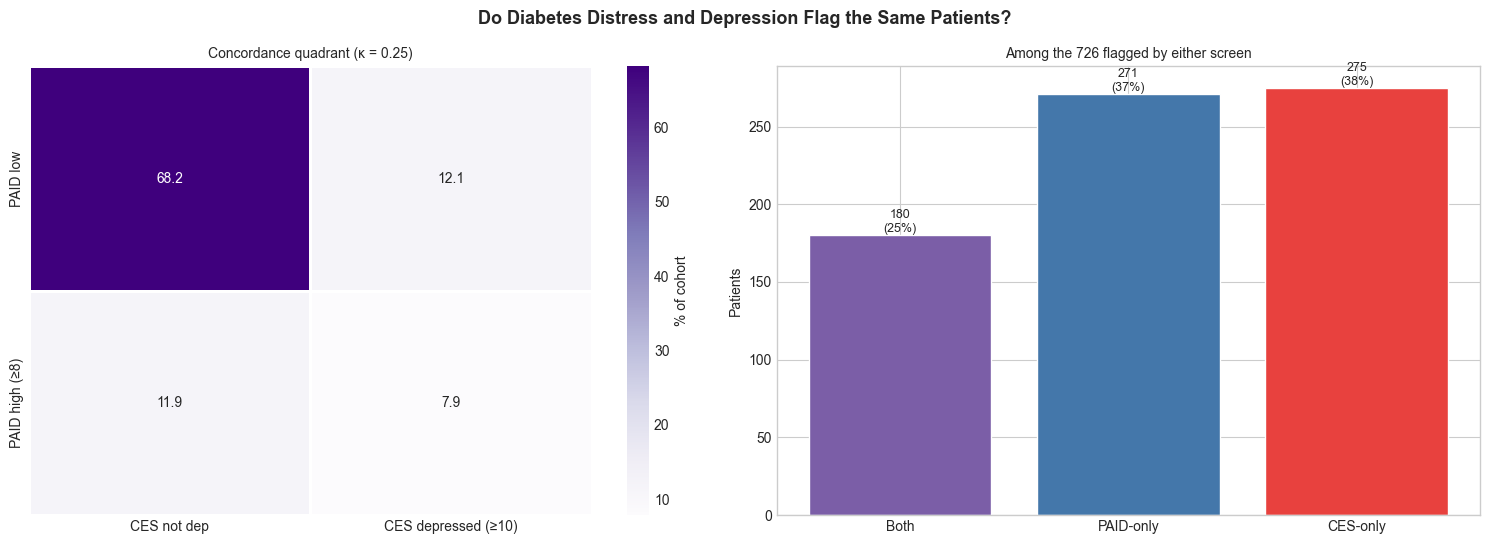

In [5]:
# ── Analysis 2: Concordance — Do the Two Screens Flag the Same People? ──
sub = df.dropna(subset=['depressed', 'high_distress']).copy()
n   = len(sub)

both_hi   = int(((sub['high_distress'] == 1) & (sub['depressed'] == 1)).sum())
paid_only = int(((sub['high_distress'] == 1) & (sub['depressed'] == 0)).sum())
ces_only  = int(((sub['high_distress'] == 0) & (sub['depressed'] == 1)).sum())
neither   = int(((sub['high_distress'] == 0) & (sub['depressed'] == 0)).sum())
flagged   = both_hi + paid_only + ces_only

ct = pd.crosstab(sub['high_distress'].map({0: 'PAID low', 1: 'PAID high (≥8)'}),
                 sub['depressed'].map({0: 'CES not dep', 1: 'CES depressed (≥10)'}))
print('=== Concordance table (counts) ===')
print(ct.to_string())

print(f'\nn = {n:,}')
print(f'  Both flagged      : {both_hi:4d} ({both_hi/n*100:4.1f}%)')
print(f'  PAID-only (distress, not depressed): {paid_only:4d} ({paid_only/n*100:4.1f}%)')
print(f'  CES-only  (depressed, not distress): {ces_only:4d} ({ces_only/n*100:4.1f}%)')
print(f'  Neither           : {neither:4d} ({neither/n*100:4.1f}%)')
print(f'\nOf everyone flagged by EITHER screen ({flagged}, {flagged/n*100:.1f}% of cohort), '
      f'only {both_hi/flagged*100:.1f}% are caught by BOTH.')

# Cohen's kappa (manual)
po     = (both_hi + neither) / n
p_paid = (both_hi + paid_only) / n
p_ces  = (both_hi + ces_only) / n
pe     = p_paid*p_ces + (1-p_paid)*(1-p_ces)
kappa  = (po - pe) / (1 - pe)
chi2, p_chi, _, _ = chi2_contingency(ct.values)
print(f"\nCohen's kappa = {kappa:.3f}  (0=chance, 1=perfect; 0.2–0.4 = fair agreement)")
print(f'Chi-square    : χ² = {chi2:.1f}, p = {p_chi:.2e}  (association is real, but far from identity)')

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Do Diabetes Distress and Depression Flag the Same Patients?',
             fontsize=13, fontweight='bold')

# Panel A: 2×2 percentage quadrant
quad = pd.DataFrame(
    [[neither/n*100, ces_only/n*100], [paid_only/n*100, both_hi/n*100]],
    index=['PAID low', 'PAID high (≥8)'],
    columns=['CES not dep', 'CES depressed (≥10)'])
sns.heatmap(quad, annot=True, fmt='.1f', cmap='Purples', linewidths=1,
            cbar_kws={'label': '% of cohort'}, ax=axes[0])
axes[0].set_title(f"Concordance quadrant (κ = {kappa:.2f})", fontsize=10)

# Panel B: of all flagged, share by both vs only-one
parts  = [both_hi, paid_only, ces_only]
labels = ['Both', 'PAID-only', 'CES-only']
colors = ['#7B5EA7', '#4477AA', '#E8413E']
axes[1].bar(labels, parts, color=colors, edgecolor='white')
for i, v in enumerate(parts):
    axes[1].text(i, v + 2, f'{v}\n({v/flagged*100:.0f}%)', ha='center', fontsize=9)
axes[1].set_ylabel('Patients')
axes[1].set_title(f'Among the {flagged} flagged by either screen', fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Analysis 3 — Correlation by Diabetes Group

> **Question**: Does the link between diabetes distress and depression depend on how severe the
> diabetes is? One might expect that in patients with little/no diabetes, "diabetes distress" is
> almost irrelevant and so decouples from depression — whereas in insulin-dependent patients the
> two could converge.
>
> **Method**: Spearman correlation between PAID-5 and CES-D-10 within each study group, FDR-corrected,
> alongside each group's high-distress and depression rates.

=== PAID-5 vs CES-D-10 correlation within each diabetes group ===
   group   n   rho  p_fdr  significant  high_distress_%  depressed_%
 Healthy 753 0.210  0.000         True           12.900       15.500
  Pre-DM 551 0.256  0.000         True           24.500       20.900
Oral Med 671 0.413  0.000         True           20.600       19.500
 Insulin 252 0.534  0.000         True           31.700       32.100


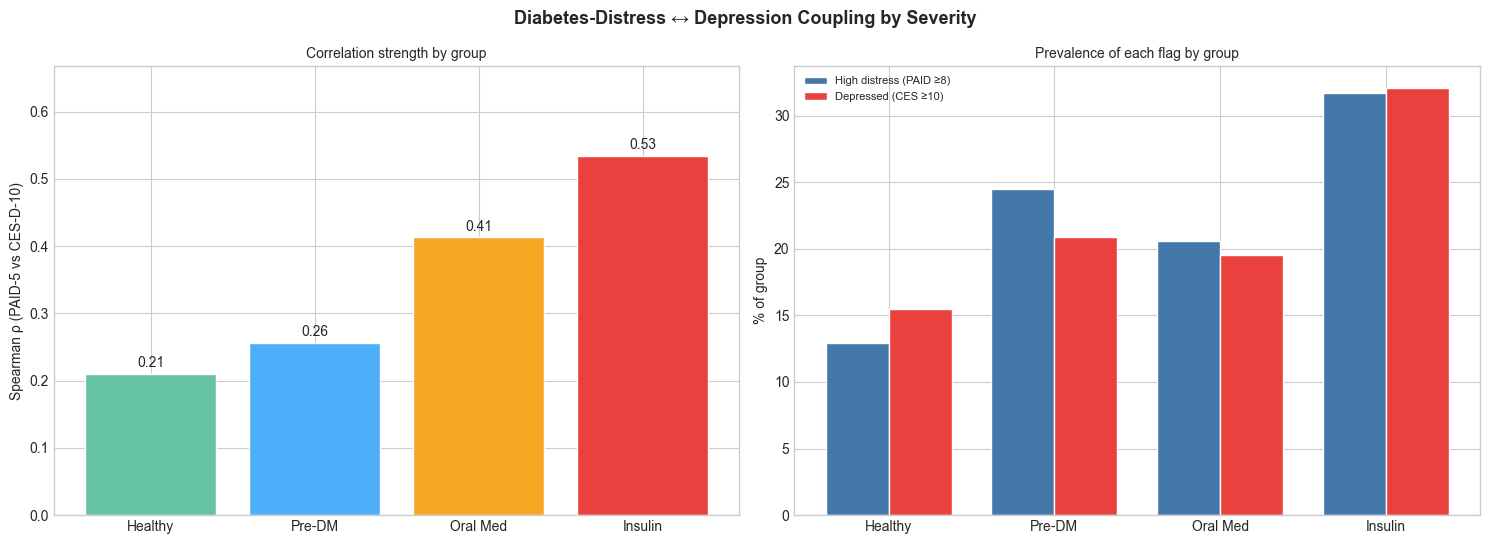

In [6]:
# ── Analysis 3: Correlation by Diabetes Group ─────────────────────
rows = []
for g in STUDY_GROUP_ORDER:
    s = both[both['study_group_label'] == g]
    if len(s) < 10:
        continue
    rho_g, p_g = spearmanr(s['cesd_total'], s['paid_total'])
    rows.append({
        'group': g, 'n': len(s),
        'rho': round(rho_g, 3), 'p': p_g,
        'high_distress_%': round((s['paid_total'] >= PAID_CUTOFF).mean()*100, 1),
        'depressed_%':     round((s['cesd_total'] >= DEPRESSION_CUTOFF).mean()*100, 1),
    })
g_df = pd.DataFrame(rows)
_, g_df['p_fdr'], _, _ = multipletests(g_df['p'], method='fdr_bh')
g_df['p_fdr'] = g_df['p_fdr'].round(4)
g_df['significant'] = g_df['p_fdr'] < 0.05

print('=== PAID-5 vs CES-D-10 correlation within each diabetes group ===')
print(g_df[['group', 'n', 'rho', 'p_fdr', 'significant',
            'high_distress_%', 'depressed_%']].to_string(index=False))

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Diabetes-Distress ↔ Depression Coupling by Severity',
             fontsize=13, fontweight='bold')

# Panel A: rho per group (severity gradient)
bar_colors = [GROUP_COLORS[g] for g in g_df['group']]
bars = axes[0].bar(g_df['group'], g_df['rho'], color=bar_colors, edgecolor='white')
for bar, r in zip(bars, g_df['rho']):
    axes[0].text(bar.get_x() + bar.get_width()/2, r + 0.01, f'{r:.2f}',
                 ha='center', fontsize=10)
axes[0].set_ylabel('Spearman ρ (PAID-5 vs CES-D-10)')
axes[0].set_title('Correlation strength by group', fontsize=10)
axes[0].set_ylim(0, max(g_df['rho']) * 1.25)

# Panel B: high-distress vs depression rate per group
x = np.arange(len(g_df))
w = 0.38
axes[1].bar(x - w/2, g_df['high_distress_%'], w, label=f'High distress (PAID ≥{PAID_CUTOFF})',
            color='#4477AA', edgecolor='white')
axes[1].bar(x + w/2, g_df['depressed_%'], w, label=f'Depressed (CES ≥{DEPRESSION_CUTOFF})',
            color='#E8413E', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(g_df['group'])
axes[1].set_ylabel('% of group')
axes[1].set_title('Prevalence of each flag by group', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
### Bootstrap robustness check — accounting for class imbalance

> The correlation by diabetes group rests on very different sample sizes (**Insulin n≈252 vs
> Healthy n≈753**), and the Insulin group shows the strongest coupling — so we should check how
> stable that estimate is. Here we resample each group **with replacement** (5,000×) for a 95%
> confidence interval around the Spearman ρ. **A CI that stays well above 0 confirms the coupling
> is real; a wide CI (Insulin) flags that its exact strength is uncertain from the smaller n.**
> Bootstrap (real patients), not SMOTE (synthetic), which would distort the correlation.

In [7]:
# ── Bootstrap 95% CIs for per-group Spearman correlation (PAID-5 vs CES-D-10) ──
def bootstrap_corr_ci(x, y, n_boot=5000, seed=0):
    x = np.asarray(x, float); y = np.asarray(y, float); n = x.size
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = spearmanr(x[idx], y[idx]).correlation
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return spearmanr(x, y).correlation, lo, hi

rows = []
for grp in STUDY_GROUP_ORDER:
    s = both[both['study_group_label'] == grp][['cesd_total', 'paid_total']].dropna()
    if len(s) < 20:
        continue
    rho, lo, hi = bootstrap_corr_ci(s['cesd_total'].values, s['paid_total'].values)
    rows.append({'group': grp, 'n': len(s), 'rho': round(rho, 3),
                 'ci_low': round(lo, 3), 'ci_high': round(hi, 3),
                 'ci_width': round(hi - lo, 3),
                 'CI_excludes_0': lo > 0})
boot_df = pd.DataFrame(rows)
print('=== Bootstrap 95% CI for PAID-5 vs CES-D-10 Spearman ρ by group (real patients) ===')
print('(CI above 0 = coupling robust; wider CI = strength less certain from smaller n)\n')
print(boot_df.to_string(index=False))

=== Bootstrap 95% CI for PAID-5 vs CES-D-10 Spearman ρ by group (real patients) ===
(CI above 0 = coupling robust; wider CI = strength less certain from smaller n)

   group   n   rho  ci_low  ci_high  ci_width  CI_excludes_0
 Healthy 753 0.210   0.138    0.278     0.140           True
  Pre-DM 551 0.256   0.177    0.333     0.156           True
Oral Med 671 0.413   0.344    0.477     0.133           True
 Insulin 252 0.534   0.435    0.618     0.183           True


---
## 7. Analysis 4 — Correlation by Age Band

> **Question**: Does the distress–depression coupling vary with age? Younger patients carry more
> depression burden (NB29); do they also show a tighter (or looser) link between the two scales?
>
> **Method**: Spearman correlation between PAID-5 and CES-D-10 within each age band (<50, 50–59,
> 60–69, 70+), FDR-corrected, with each band's high-distress and depression rates.

=== PAID-5 vs CES-D-10 correlation within each age band ===
age_band   n   rho  p_fdr  significant  high_distress_%  depressed_%
     <50 418 0.324  0.000         True           28.000       29.200
   50–59 556 0.328  0.000         True           25.000       25.400
   60–69 703 0.293  0.000         True           16.600       16.400
     70+ 550 0.297  0.000         True           14.000       12.000


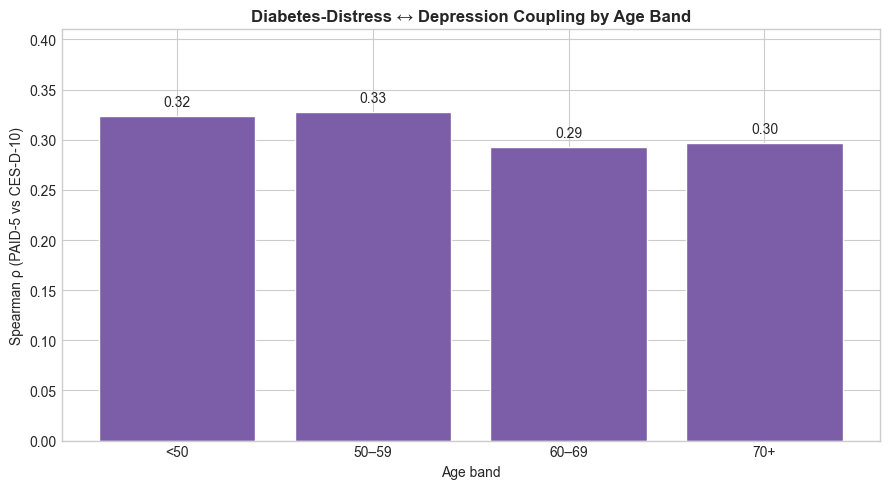

In [8]:
# ── Analysis 4: Correlation by Age Band ───────────────────────────
rows = []
for b in AGE_BAND_LABELS:
    s = both[both['age_band'] == b]
    if len(s) < 10:
        continue
    rho_b, p_b = spearmanr(s['cesd_total'], s['paid_total'])
    rows.append({
        'age_band': b, 'n': len(s),
        'rho': round(rho_b, 3), 'p': p_b,
        'high_distress_%': round((s['paid_total'] >= PAID_CUTOFF).mean()*100, 1),
        'depressed_%':     round((s['cesd_total'] >= DEPRESSION_CUTOFF).mean()*100, 1),
    })
a_df = pd.DataFrame(rows)
_, a_df['p_fdr'], _, _ = multipletests(a_df['p'], method='fdr_bh')
a_df['p_fdr'] = a_df['p_fdr'].round(4)
a_df['significant'] = a_df['p_fdr'] < 0.05

print('=== PAID-5 vs CES-D-10 correlation within each age band ===')
print(a_df[['age_band', 'n', 'rho', 'p_fdr', 'significant',
            'high_distress_%', 'depressed_%']].to_string(index=False))

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(a_df['age_band'], a_df['rho'], color='#7B5EA7', edgecolor='white')
for bar, r in zip(bars, a_df['rho']):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.01, f'{r:.2f}', ha='center', fontsize=10)
ax.set_ylabel('Spearman ρ (PAID-5 vs CES-D-10)')
ax.set_xlabel('Age band')
ax.set_title('Diabetes-Distress ↔ Depression Coupling by Age Band',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(a_df['rho']) * 1.25)
plt.tight_layout()
plt.show()

---
## 8. Analysis 5 — Item-Level: Which Distress Facets Track Depression?

> **Question**: PAID-5 has five facets — worry about the future, fear of living with diabetes,
> feeling depressed about diabetes, coping with complications, and diabetes consuming mental
> energy. Which of these individual diabetes-distress items align most with general depression?
> Is the overlap driven only by the one depression-flavoured item, or is it broad?
>
> **Method**: Spearman correlation between each PAID-5 item (0–4) and the CES-D-10 total,
> FDR-corrected, ranked.

=== Each PAID-5 item vs CES-D-10 total (Spearman) ===
                                         label  mean_item  rho_with_cesd  p_fdr  significant    n
     Worrying about the future / complications      1.070          0.334  0.000         True 2223
Feeling depressed when thinking about diabetes      0.740          0.324  0.000         True 2221
     Diabetes taking up too much mental energy      0.540          0.286  0.000         True 2220
     Feeling scared about living with diabetes      0.980          0.257  0.000         True 2225
         Coping with complications of diabetes      0.670          0.247  0.000         True 2219


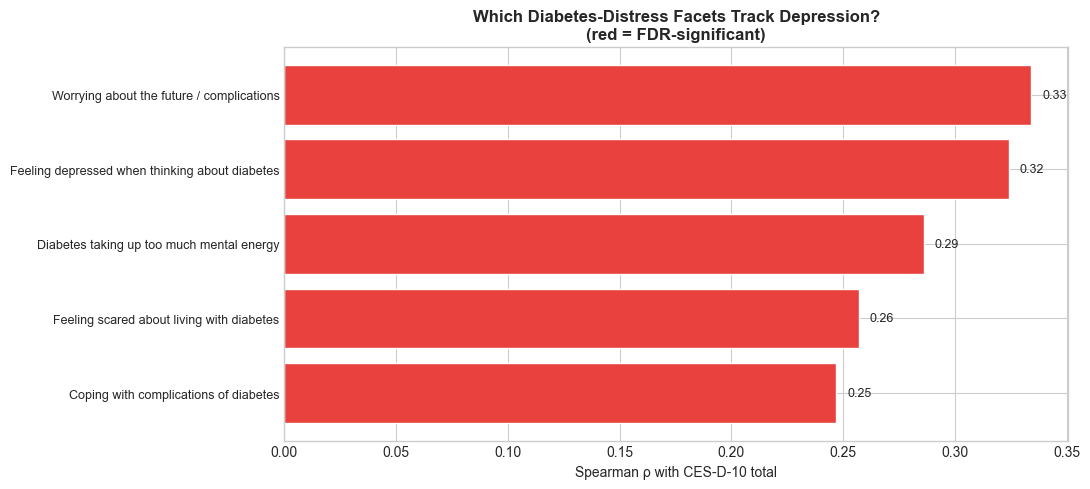

In [9]:
# ── Analysis 5: Item-Level — Which Distress Facets Track Depression? ──
rows = []
for k in ITEM_COLS:
    s = df.dropna(subset=['cesd_total', k])
    if len(s) < 10:
        continue
    rho_i, p_i = spearmanr(s['cesd_total'], s[k])
    rows.append({'item': k, 'label': PAID_ITEMS[k],
                 'mean_item': round(df[k].mean(), 2),
                 'rho_with_cesd': round(rho_i, 3), 'p': p_i, 'n': len(s)})
it = pd.DataFrame(rows)
_, it['p_fdr'], _, _ = multipletests(it['p'], method='fdr_bh')
it['p_fdr'] = it['p_fdr'].round(4)
it['significant'] = it['p_fdr'] < 0.05
it = it.sort_values('rho_with_cesd', ascending=False).reset_index(drop=True)

print('=== Each PAID-5 item vs CES-D-10 total (Spearman) ===')
print(it[['label', 'mean_item', 'rho_with_cesd', 'p_fdr', 'significant', 'n']].to_string(index=False))

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = it.sort_values('rho_with_cesd')
colors = ['#E8413E' if s else '#cccccc' for s in plot_df['significant']]
bars = ax.barh(plot_df['label'], plot_df['rho_with_cesd'], color=colors, edgecolor='white')
for bar, r in zip(bars, plot_df['rho_with_cesd']):
    ax.text(r + 0.005, bar.get_y() + bar.get_height()/2, f'{r:.2f}',
            va='center', fontsize=9)
ax.set_xlabel('Spearman ρ with CES-D-10 total')
ax.set_title('Which Diabetes-Distress Facets Track Depression?\n(red = FDR-significant)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

---
## Key Findings

> Full interpretation lives in this notebook's report. Numbers below are from the analysis cells above.

**Diabetes distress (PAID-5) and depression (CES-D-10) are related but distinct — they flag largely different patients, and the two only converge as diabetes severity rises.**

1. **Overall correlation is moderate, not redundant** (Analysis 1): Spearman ρ ≈ **0.33** (Pearson r ≈ 0.37) — the two scales share only ~11% of rank variance. Both are right-skewed and have near-identical flag rates overall (PAID high ≈ 20.2%, depressed ≈ 19.9%), yet they are far from measuring the same thing.

2. **They flag mostly different people** (Analysis 2): of everyone caught by *either* screen (~32% of the cohort), only **~8% of the cohort is flagged by both** — about a quarter of the flagged group. **~12% are distress-only** (high PAID, not depressed) and **~12% are depression-only**. Cohen's κ ≈ 0.2–0.3 (fair). **Screening with only one instrument would miss roughly half of the at-risk patients the other would catch.**

3. **The coupling strengthens steeply with diabetes severity** (Analysis 3): ρ climbs Healthy **0.21** → Pre-DM **0.26** → Oral Med **0.41** → **Insulin 0.53**. In people without diabetes the two are nearly independent; in insulin-dependent patients they strongly converge — diabetes-specific distress and general depression increasingly feed each other as the disease advances. High-distress and depression rates both peak in Insulin (~32%).

4. **Coupling is broadly stable across age** (Analysis 4): ρ is significant in every age band and only drifts mildly — <50 **0.32**, 50–59 **0.33**, 60–69 **0.29**, 70+ **0.30** (slightly tighter in under-60s). There is no steep age gradient like the one seen across diabetes groups.

5. **The overlap is broad, not one item** (Analysis 5): every PAID-5 facet correlates with depression. The strongest are **"worrying about the future"** (ρ ≈ 0.33) and **"feeling depressed about diabetes"** (ρ ≈ 0.32) — note the link is *not* driven solely by the depression-flavoured item; worry, low energy, fear and coping all contribute.

**Key takeaway**: PAID-5 and CES-D-10 capture overlapping but separable burden. A diabetes clinic that screens for only one will systematically miss patients flagged by the other, and the distinction matters most in milder diabetes (where the scales diverge) — while in insulin-dependent patients the two largely coincide.